# Loading libraries

In [1]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# TASK 1


# 1.1 Multiple-feature extension


In [2]:
# Load AAPL data
AAPL = pd.read_csv('Nasdaq data/csv/AAPL.csv')

In [3]:
# Load MSFT data
MSFT = pd.read_csv('Nasdaq data/csv/MSFT.csv')

In [4]:
# Load NVDA data
NVDA = pd.read_csv('Nasdaq data/csv/NVDA.csv')

In [5]:
# Show some first data samples for AAPL
AAPL.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


In [6]:
# Get some info about the AAPL data
display(AAPL.info())
print("="*75)
# Get some info about the MSFT data
MSFT.info()
print("="*75)
# Get some info about the NVDA data
NVDA.info()

<class 'pandas.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10590 non-null  str    
 1   Low             10590 non-null  float64
 2   Open            10590 non-null  float64
 3   Volume          10590 non-null  int64  
 4   High            10590 non-null  float64
 5   Close           10590 non-null  float64
 6   Adjusted Close  10590 non-null  float64
dtypes: float64(5), int64(1), str(1)
memory usage: 682.7 KB


None

<class 'pandas.DataFrame'>
RangeIndex: 9264 entries, 0 to 9263
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            9264 non-null   str    
 1   Low             9264 non-null   float64
 2   Open            9264 non-null   float64
 3   Volume          9264 non-null   int64  
 4   High            9264 non-null   float64
 5   Close           9264 non-null   float64
 6   Adjusted Close  9264 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 597.2 KB
<class 'pandas.DataFrame'>
RangeIndex: 6013 entries, 0 to 6012
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            6013 non-null   str    
 1   Low             6013 non-null   float64
 2   Open            6013 non-null   float64
 3   Volume          6013 non-null   int64  
 4   High            6013 non-null   float64
 5   Close           6013 non-

### Data pipeline

**Features added** (none of these are in the raw CSVs):

| Feature | Formula | Meaning |
|---|---|---|
| `daily_return` | `Close.pct_change()` | Day-over-day % change |
| `MA5`, `MA20` | rolling mean of `Close`, 5 / 20 days | Short / medium-term trend |
| `RSI` (14) | `100 − 100 / (1 + avg_gain / avg_loss)` over 14 days | Momentum, range [0, 100]. >70 overbought, <30 oversold |
| `MACD` | `EMA12(Close) − EMA26(Close)` | Trend-following momentum |
| `MACD_signal` | `EMA9(MACD)` | Smoothed MACD; crossovers signal trend changes |
| `volatility` | rolling std of `daily_return`, 20 days | Risk / price stability |

All indicators are **causal** (only look backward), so computing them on the full series before splitting introduces no future leakage.


In [7]:
# Technical indicators — all causal (look only at past values)
def add_technical_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(out['Date']):
        out['Date'] = pd.to_datetime(out['Date'], format='%d-%m-%Y')
    out = out.sort_values('Date').reset_index(drop=True)

    out['daily_return'] = out['Close'].pct_change()
    out['MA5']  = out['Close'].rolling(5).mean()
    out['MA20'] = out['Close'].rolling(20).mean()

    delta = out['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-8)
    out['RSI'] = 100 - 100 / (1 + rs)

    ema12 = out['Close'].ewm(span=12, adjust=False).mean()
    ema26 = out['Close'].ewm(span=26, adjust=False).mean()
    out['MACD']        = ema12 - ema26
    out['MACD_signal'] = out['MACD'].ewm(span=9, adjust=False).mean()

    out['volatility'] = out['daily_return'].rolling(20).std()
    return out


**Pipeline:** add features → build sliding windows → chronological split (70 / 15 / 15) → **per-window MinMax** normalisation (matches the sample-code style: each window is normalised by its own min / max).

- **Input** — every feature in `FEATURE_COLS` (OHLCV, Adjusted Close, and the 7 engineered indicators) — shape `(N, window_size, n_features)`.
- **Label** — `Adjusted Close` `horizon` days after the window. Splits are **dividend / split adjusted**, which matters on AAPL's 30+ year history.
- **Per-window MinMax** — for each window, every feature is normalised independently by its own min / max over the 30 timesteps. The label uses the *Adjusted Close column's* window min / max (so we can denormalise predictions back to dollars).

Returns three `Split` namedtuples (`train`, `val`, `test`), each with `.X`, `.y`, `.label_min`, `.label_max`. Use `denormalize_label(...)` on predictions to recover real prices.


In [8]:
from typing import NamedTuple
from sklearn.model_selection import train_test_split

FEATURE_COLS = ['Open', 'High', 'Low', 'Close', 'Volume', 'Adjusted Close',
                'daily_return', 'MA5', 'MA20', 'RSI',
                'MACD', 'MACD_signal', 'volatility']
LABEL_COL = 'Adjusted Close'


class Split(NamedTuple):
    X:         np.ndarray  # (N, window_size, n_features), float32, in [0, 1]
    y:         np.ndarray  # (N,)                          float32, in [0, 1]
    label_min: np.ndarray  # (N,)  per-window Adj Close min — for denormalisation
    label_max: np.ndarray  # (N,)  per-window Adj Close max


def build_pipeline(df, name, window_size=30, horizon=1,
                   val_ratio=0.15, test_ratio=0.15, verbose=True):
    """Add features → window → chronological split → per-window MinMax."""
    feat = add_technical_features(df).dropna().reset_index(drop=True)
    label_idx = FEATURE_COLS.index(LABEL_COL)

    arr   = feat[FEATURE_COLS].values.astype(np.float32)
    label = feat[LABEL_COL].values.astype(np.float32)

    # Sliding windows: X = (window_size, n_features), y = Adj Close at t + horizon
    X_list, y_list = [], []
    for i in range(len(arr) - window_size - horizon + 1):
        X_list.append(arr[i : i + window_size])
        y_list.append(label[i + window_size + horizon - 1])
    X = np.stack(X_list)
    y = np.array(y_list, dtype=np.float32)

    # Chronological split (shuffle=False) — same pattern as the sample notebook
    X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=test_ratio, shuffle=False)
    val_size_adj = val_ratio / (1 - test_ratio)
    X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=val_size_adj, shuffle=False)

    def normalise(Xs, ys):
        # Per-window, per-feature MinMax (axis=1 → time axis only)
        fmins = Xs.min(axis=1, keepdims=True)              # (N, 1, F)
        fmaxs = Xs.max(axis=1, keepdims=True)
        Xn = (Xs - fmins) / (fmaxs - fmins + 1e-8)
        # Label uses the Adjusted Close column's per-window stats so it can be denormalised
        lmin = fmins[:, 0, label_idx]                      # (N,)
        lmax = fmaxs[:, 0, label_idx]
        yn = (ys - lmin) / (lmax - lmin + 1e-8)
        return Split(Xn.astype(np.float32), yn.astype(np.float32), lmin, lmax)

    train, val, test = normalise(X_train, y_train), normalise(X_val, y_val), normalise(X_test, y_test)

    if verbose:
        print(f"[{name:5s}]  X_train: {train.X.shape}  X_val: {val.X.shape}  "
              f"X_test: {test.X.shape}  (window={window_size}, horizon={horizon}, "
              f"n_features={train.X.shape[-1]})")

    return train, val, test


def denormalize_label(y_norm, label_min, label_max):
    """Invert per-window MinMax for predictions:
        y_pred_real = denormalize_label(model.predict(test.X).ravel(),
                                        test.label_min, test.label_max)
    """
    return y_norm * (label_max - label_min + 1e-8) + label_min


In [9]:
# Run pipeline for each ticker → produces <name>_train / _val / _test (each is a Split namedtuple)
AAPL_train, AAPL_val, AAPL_test = build_pipeline(AAPL, 'AAPL')
MSFT_train, MSFT_val, MSFT_test = build_pipeline(MSFT, 'MSFT')
NVDA_train, NVDA_val, NVDA_test = build_pipeline(NVDA, 'NVDA')


[AAPL ]  X_train: (7378, 30, 13)  X_val: (1581, 30, 13)  X_test: (1581, 30, 13)  (window=30, horizon=1, n_features=13)
[MSFT ]  X_train: (6449, 30, 13)  X_val: (1382, 30, 13)  X_test: (1383, 30, 13)  (window=30, horizon=1, n_features=13)
[NVDA ]  X_train: (4173, 30, 13)  X_val: (895, 30, 13)  X_test: (895, 30, 13)  (window=30, horizon=1, n_features=13)


### AAPL train / validation / test split visualization

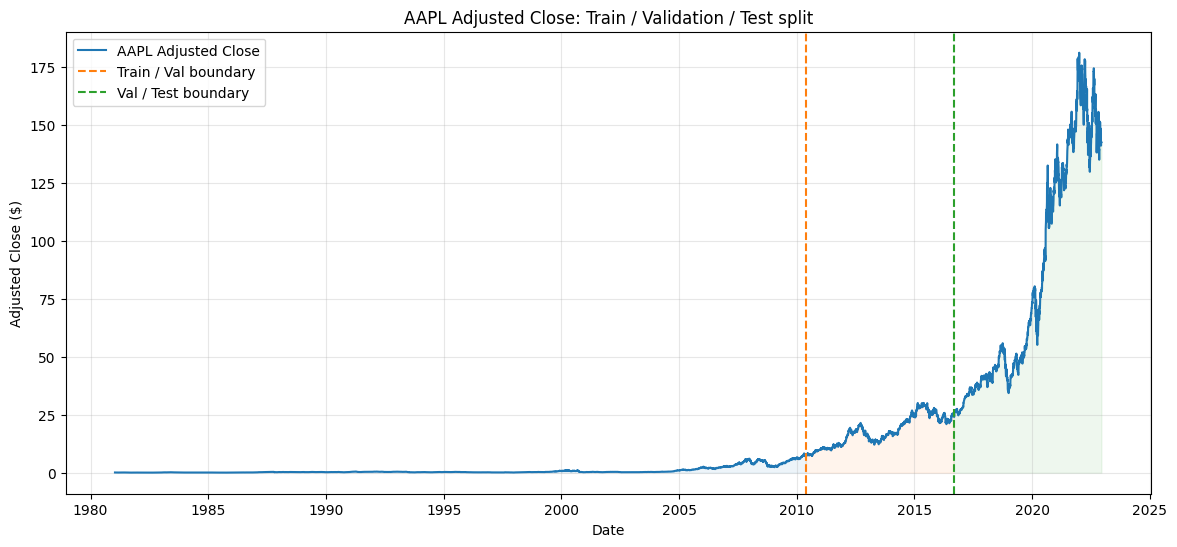

In [10]:
# Plot the AAPL adjusted close trend with chronological split boundaries from the pipeline.
window_size = 30
feat = add_technical_features(AAPL).dropna().reset_index(drop=True)
feat['Date'] = pd.to_datetime(feat['Date'], errors='coerce')
feat = feat.sort_values('Date').reset_index(drop=True)

train_end = AAPL_train.X.shape[0] + window_size - 1
val_end = train_end + AAPL_val.X.shape[0]

plt.figure(figsize=(14, 6))
plt.plot(feat['Date'], feat['Adjusted Close'], label='AAPL Adjusted Close', color='tab:blue')
plt.axvline(feat.loc[train_end, 'Date'], color='tab:orange', linestyle='--', label='Train / Val boundary')
plt.axvline(feat.loc[val_end, 'Date'], color='tab:green', linestyle='--', label='Val / Test boundary')
plt.fill_between(feat['Date'][:train_end+1], feat['Adjusted Close'][:train_end+1], color='tab:blue', alpha=0.08)
plt.fill_between(feat['Date'][train_end+1:val_end+1], feat['Adjusted Close'][train_end+1:val_end+1], color='tab:orange', alpha=0.08)
plt.fill_between(feat['Date'][val_end+1:], feat['Adjusted Close'][val_end+1:], color='tab:green', alpha=0.08)
plt.title('AAPL Adjusted Close: Train / Validation / Test split')
plt.xlabel('Date')
plt.ylabel('Adjusted Close ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [11]:
# Sanity checks: shapes, normalisation range, label denormalisation
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Label: {LABEL_COL!r}\n")

for name, tr, va, te in [('AAPL', AAPL_train, AAPL_val, AAPL_test),
                         ('MSFT', MSFT_train, MSFT_val, MSFT_test),
                         ('NVDA', NVDA_train, NVDA_val, NVDA_test)]:
    print(f"[{name}]  X_train {tr.X.shape}  y_train {tr.y.shape}  "
          f"|  X_val {va.X.shape}  |  X_test {te.X.shape}")
    print(f"        X (must be [0, 1]): [{tr.X.min():.3f}, {tr.X.max():.3f}]   "
          f"y (can exceed [0, 1] when day t+1 breaks the window's range): "
          f"[{tr.y.min():.3f}, {tr.y.max():.3f}]")

# Round-trip check: denormalise the first 3 test labels back to dollars
y_recovered = denormalize_label(AAPL_test.y[:3], AAPL_test.label_min[:3], AAPL_test.label_max[:3])
print(f"\nAAPL test labels denormalised → {y_recovered.round(3).tolist()}  (real Adjusted Close prices)")


Features (13): ['Open', 'High', 'Low', 'Close', 'Volume', 'Adjusted Close', 'daily_return', 'MA5', 'MA20', 'RSI', 'MACD', 'MACD_signal', 'volatility']
Label: 'Adjusted Close'

[AAPL]  X_train (7378, 30, 13)  y_train (7378,)  |  X_val (1581, 30, 13)  |  X_test (1581, 30, 13)
        X (must be [0, 1]): [0.000, 1.000]   y (can exceed [0, 1] when day t+1 breaks the window's range): [-1.599, 2.000]
[MSFT]  X_train (6449, 30, 13)  y_train (6449,)  |  X_val (1382, 30, 13)  |  X_test (1383, 30, 13)
        X (must be [0, 1]): [0.000, 1.000]   y (can exceed [0, 1] when day t+1 breaks the window's range): [-2.562, 1.984]
[NVDA]  X_train (4173, 30, 13)  y_train (4173,)  |  X_val (895, 30, 13)  |  X_test (895, 30, 13)
        X (must be [0, 1]): [0.000, 1.000]   y (can exceed [0, 1] when day t+1 breaks the window's range): [-0.812, 2.489]

AAPL test labels denormalised → [24.843000411987305, 25.076000213623047, 25.069000244140625]  (real Adjusted Close prices)


In [12]:
# Train AAPL LSTM (LSTM replaces the sample's Conv1D per the project spec; same MSE/Adam pattern)
AAPL_LSTM_model = Sequential([
    Input(shape=AAPL_train.X.shape[1:]),    # (window_size, n_features) = (30, 13)
    LSTM(64),
    Dense(1),
])
AAPL_LSTM_model.compile(optimizer='adam', loss='mse', metrics=['mse'])
history = AAPL_LSTM_model.fit(
    AAPL_train.X, AAPL_train.y,
    validation_data=(AAPL_val.X, AAPL_val.y),
    epochs=10, batch_size=64,
    verbose=1,
)


Epoch 1/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0866 - mse: 0.0866 - val_loss: 0.0366 - val_mse: 0.0366
Epoch 2/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0320 - mse: 0.0320 - val_loss: 0.0266 - val_mse: 0.0266
Epoch 3/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0284 - mse: 0.0284 - val_loss: 0.0252 - val_mse: 0.0252
Epoch 4/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0278 - mse: 0.0278 - val_loss: 0.0254 - val_mse: 0.0254
Epoch 5/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0274 - mse: 0.0274 - val_loss: 0.0271 - val_mse: 0.0271
Epoch 6/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0274 - mse: 0.0274 - val_loss: 0.0250 - val_mse: 0.0250
Epoch 7/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0267 - mse: 0.0267 - val_loss: 0.0251 - val_mse: 0.0251
Epoch 8/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0272 - mse: 0.0272 - val_loss: 0.0248 - val_mse: 0.0248
Epoch 9/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - 

### Training curves


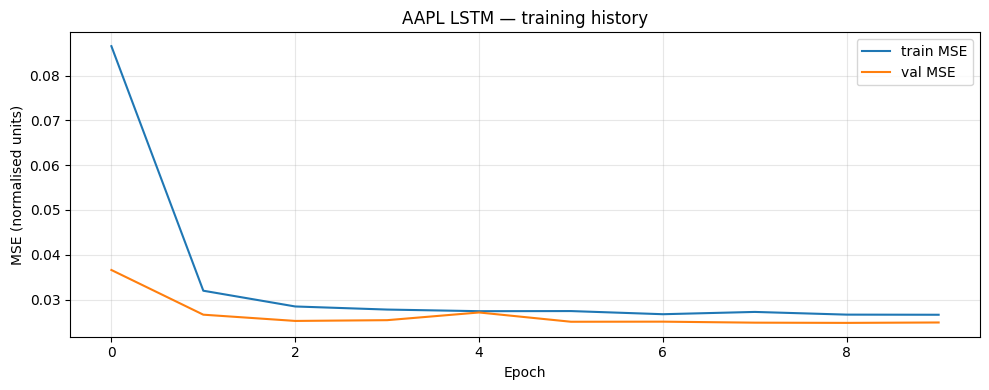

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='train MSE', color='tab:blue')
plt.plot(history.history['val_loss'], label='val MSE',   color='tab:orange')
plt.title('AAPL LSTM — training history')
plt.xlabel('Epoch')
plt.ylabel('MSE (normalised units)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Test set evaluation — denormalise back to dollar units


In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict on test, then invert per-window MinMax → real Adjusted Close in dollars
y_pred_norm = AAPL_LSTM_model.predict(AAPL_test.X, verbose=0).ravel()
y_pred = denormalize_label(y_pred_norm, AAPL_test.label_min, AAPL_test.label_max)
y_real = denormalize_label(AAPL_test.y,  AAPL_test.label_min, AAPL_test.label_max)

mse_norm = mean_squared_error(AAPL_test.y, y_pred_norm)
mse_dol  = mean_squared_error(y_real, y_pred)
rmse_dol = np.sqrt(mse_dol)
mae_dol  = mean_absolute_error(y_real, y_pred)

print(f"AAPL test set  ({len(y_pred)} samples):")
print(f"  MSE  (normalised)  : {mse_norm:.5f}   ← compare with sample's 0.033")
print(f"  MSE  ($²)          : {mse_dol:.4f}")
print(f"  RMSE ($)           : {rmse_dol:.4f}")
print(f"  MAE  ($)           : {mae_dol:.4f}")


AAPL test set  (1581 samples):
  MSE  (normalised)  : 0.02466   ← compare with sample's 0.033
  MSE  ($²)          : 4.0539
  RMSE ($)           : 2.0134
  MAE  ($)           : 1.2391


### Predicted vs real Adjusted Close (AAPL test set)


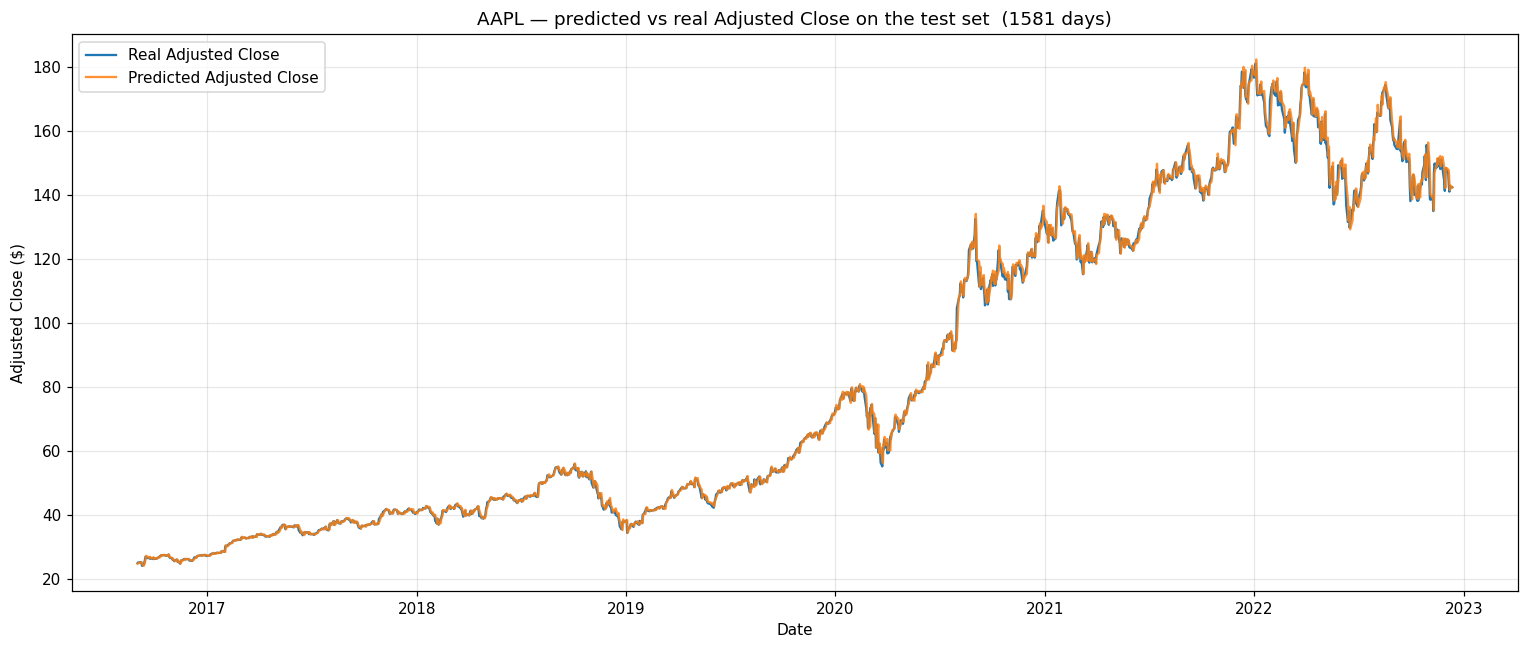

In [15]:
# Recover the calendar date for each test label so x-axis is real time, not row index
window_size, horizon = 30, 1
feat_aapl = add_technical_features(AAPL).dropna().reset_index(drop=True)
test_start_idx = AAPL_train.X.shape[0] + AAPL_val.X.shape[0]
test_label_dates = feat_aapl['Date'].iloc[
    test_start_idx + window_size + horizon - 1 :
    test_start_idx + window_size + horizon - 1 + len(y_pred)
].reset_index(drop=True)

plt.figure(figsize=(14, 6), dpi=110)
plt.plot(test_label_dates, y_real, label='Real Adjusted Close',     color='tab:blue')
plt.plot(test_label_dates, y_pred, label='Predicted Adjusted Close', color='tab:orange', alpha=0.85)
plt.title(f'AAPL — predicted vs real Adjusted Close on the test set  ({len(y_pred)} days)')
plt.xlabel('Date')
plt.ylabel('Adjusted Close ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 1.2 kᵗʰ day forecast

Task 1.1 predicts the **next** day (`horizon = 1`). Task 1.2 instead predicts the price on the **kᵗʰ day after the input window** — e.g., the 3rd or 7th day ahead.

The `build_pipeline(..., horizon=k)` helper from 1.1 already supports this: each label is `label[i + window_size + k - 1]`, i.e., the kᵗʰ day after the window ends. So 1.2 reuses the same pipeline, model, and training loop — only `horizon` changes.

We re-train the AAPL LSTM at **k ∈ {3, 7}**, identical architecture and hyperparameters as 1.1, and compare against the k = 1 baseline. As expected, forecast error grows with k — the further ahead we predict, the less the recent 30-day window carries information about the target day.

In [16]:
# Build pipelines and train LSTMs for k ∈ {3, 7} — same architecture & hyperparameters as 1.1
def build_lstm(input_shape):
    """Same architecture as the AAPL model from 1.1: LSTM(64) → Dense(1)."""
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64),
        Dense(1),
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mse'])
    return model


K_VALUES = [3, 7]
results_kth = {}  # k → dict(model, history, train, val, test)

for k in K_VALUES:
    tr, va, te = build_pipeline(AAPL, f'AAPL k={k}', horizon=k)
    model = build_lstm(tr.X.shape[1:])
    history = model.fit(
        tr.X, tr.y,
        validation_data=(va.X, va.y),
        epochs=10, batch_size=64, verbose=0,
    )
    results_kth[k] = {'model': model, 'history': history,
                      'train': tr, 'val': va, 'test': te}
    print(f"  → k={k}: trained on {tr.X.shape[0]} windows, "
          f"final val_loss = {history.history['val_loss'][-1]:.5f}")

[AAPL k=3]  X_train: (7376, 30, 13)  X_val: (1581, 30, 13)  X_test: (1581, 30, 13)  (window=30, horizon=3, n_features=13)
  → k=3: trained on 7376 windows, final val_loss = 0.07879
[AAPL k=7]  X_train: (7373, 30, 13)  X_val: (1580, 30, 13)  X_test: (1581, 30, 13)  (window=30, horizon=7, n_features=13)
  → k=7: trained on 7373 windows, final val_loss = 0.18901


### Test-set comparison: k = 1 vs k = 3 vs k = 7

All metrics are computed on the **denormalised** test predictions (real Adjusted Close dollars), so the numbers are directly comparable across k. The k = 1 row is re-evaluated from the model trained in 1.1.

In [17]:
def evaluate_test(model, test):
    """Predict on the test split, denormalise, and return (y_real, y_pred, metrics-dict)."""
    y_pred_norm = model.predict(test.X, verbose=0).ravel()
    y_pred = denormalize_label(y_pred_norm, test.label_min, test.label_max)
    y_real = denormalize_label(test.y,      test.label_min, test.label_max)
    mse_norm = mean_squared_error(test.y, y_pred_norm)
    mse_dol  = mean_squared_error(y_real, y_pred)
    return y_real, y_pred, {
        'MSE (norm)': mse_norm,
        'MSE ($²)':   mse_dol,
        'RMSE ($)':   np.sqrt(mse_dol),
        'MAE ($)':    mean_absolute_error(y_real, y_pred),
    }


# k = 1 baseline (from 1.1)
_, _, m1 = evaluate_test(AAPL_LSTM_model, AAPL_test)
rows = [(1, m1)] + [(k, evaluate_test(r['model'], r['test'])[2]) for k, r in results_kth.items()]

print(f"AAPL — kᵗʰ day forecast comparison\n")
print(f"{'k':>3}  {'MSE (norm)':>11}  {'MSE ($²)':>10}  {'RMSE ($)':>10}  {'MAE ($)':>10}")
print('-' * 52)
for k, m in rows:
    print(f"{k:>3}  {m['MSE (norm)']:>11.5f}  {m['MSE ($²)']:>10.4f}  "
          f"{m['RMSE ($)']:>10.4f}  {m['MAE ($)']:>10.4f}")

AAPL — kᵗʰ day forecast comparison

  k   MSE (norm)    MSE ($²)    RMSE ($)     MAE ($)
----------------------------------------------------
  1      0.02466      4.0539      2.0134      1.2391
  3      0.07650     11.1539      3.3397      2.1062
  7      0.18486     25.0578      5.0058      3.2928


### Predicted vs real Adjusted Close — k = 3 and k = 7 test sets

Both panels use real calendar dates on the x-axis. The label for the iᵗʰ test window lands at original index `i + N_train + N_val + window_size + k − 1` in the feature-engineered AAPL series.

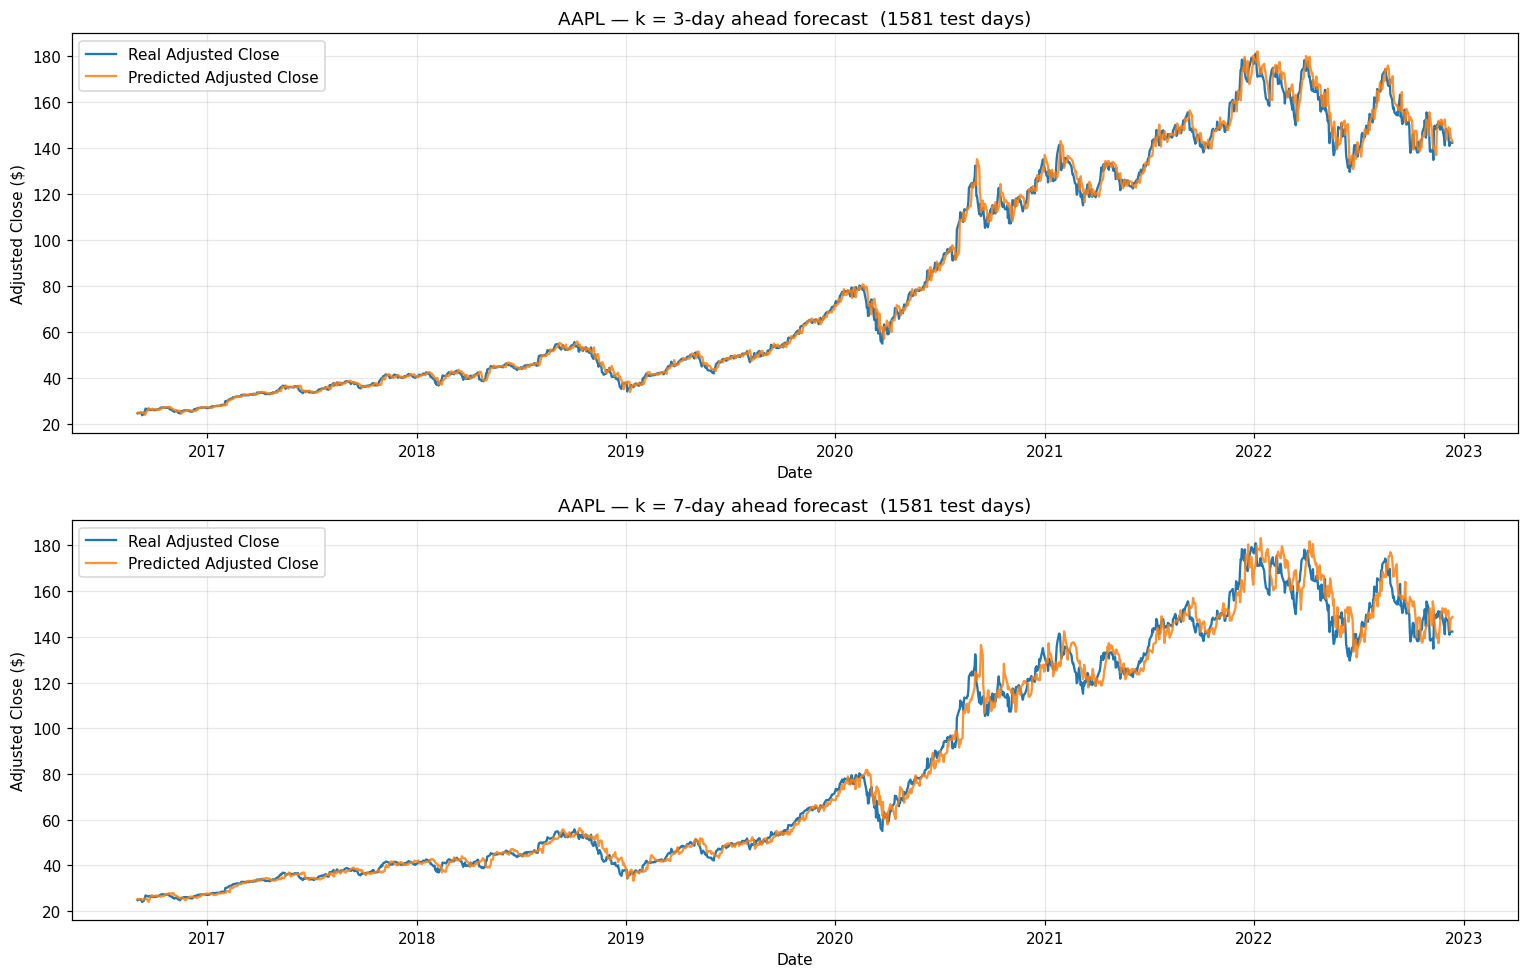

In [18]:
window_size = 30
fig, axes = plt.subplots(2, 1, figsize=(14, 9), dpi=110)

for ax, k in zip(axes, K_VALUES):
    r = results_kth[k]
    y_real, y_pred, _ = evaluate_test(r['model'], r['test'])

    test_start_idx = r['train'].X.shape[0] + r['val'].X.shape[0]
    label_offset   = window_size + k - 1
    dates = feat_aapl['Date'].iloc[
        test_start_idx + label_offset :
        test_start_idx + label_offset + len(y_pred)
    ].reset_index(drop=True)

    ax.plot(dates, y_real, label='Real Adjusted Close',      color='tab:blue')
    ax.plot(dates, y_pred, label='Predicted Adjusted Close', color='tab:orange', alpha=0.85)
    ax.set_title(f'AAPL — k = {k}-day ahead forecast  ({len(y_pred)} test days)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Adjusted Close ($)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()